In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/indian-accents/kaggle_setup_check.py
/kaggle/input/indian-accents/KAGGLE_README.md
/kaggle/input/indian-accents/requirements.txt
/kaggle/input/indian-accents/scripts/layerwise_hubert_analysis.py
/kaggle/input/indian-accents/scripts/compare_word_sentence_level.py
/kaggle/input/indian-accents/scripts/create_word_level_dataset.py
/kaggle/input/indian-accents/src/__init__.py
/kaggle/input/indian-accents/src/utils/__init__.py
/kaggle/input/indian-accents/src/features/dataset.py
/kaggle/input/indian-accents/src/features/__init__.py
/kaggle/input/indian-accents/src/features/hubert_extractor.py
/kaggle/input/indian-accents/src/models/mlp.py
/kaggle/input/indian-accents/src/models/__init__.py
/kaggle/input/indian-accents/src/data/create_splits.py
/kaggle/input/indian-accents/src/data/__init__.py
/kaggle/input/indian-accents/data/splits/val.csv
/kaggle/input/indian-accents/data/splits/train.csv
/kaggle/input/indian-accents/data/splits/test.csv
/kaggle/input/indian-accents/data/raw/

In [2]:
# Cell 1: Find where your files are
import os

# List what's in the dataset
print("Files in /kaggle/input/indian-accents/:")
!ls -la /kaggle/input/indian-accents/

# Check all input folders
print("\nAll datasets:")
!ls -la /kaggle/input/

Files in /kaggle/input/indian-accents/:
total 16
drwxr-xr-x 5 nobody nogroup    0 Nov 11 04:41 .
drwxr-xr-x 3 root   root    4096 Nov 11 04:41 ..
drwxr-xr-x 4 nobody nogroup    0 Nov 11 04:41 data
-rw-r--r-- 1 nobody nogroup 1887 Nov 11 04:40 KAGGLE_README.md
-rw-r--r-- 1 nobody nogroup 1970 Nov 11 04:41 kaggle_setup_check.py
-rw-r--r-- 1 nobody nogroup  873 Nov 11 04:41 requirements.txt
drwxr-xr-x 2 nobody nogroup    0 Nov 11 04:41 scripts
drwxr-xr-x 6 nobody nogroup    0 Nov 11 04:41 src

All datasets:
total 8
drwxr-xr-x 3 root   root    4096 Nov 11 04:41 .
drwxr-xr-x 5 root   root    4096 Nov 11 04:41 ..
drwxr-xr-x 5 nobody nogroup    0 Nov 11 04:41 indian-accents


In [3]:
# Cell 1: Copy files from input to working directory
import shutil
from pathlib import Path
import os

src = Path('/kaggle/input/indian-accents')
dst = Path('/kaggle/working')

# Copy all directories and files
for item in src.iterdir():
    if item.is_dir():
        shutil.copytree(item, dst / item.name, dirs_exist_ok=True)
        print(f"✓ Copied {item.name}/")
    else:
        shutil.copy2(item, dst / item.name)
        print(f"✓ Copied {item.name}")

os.chdir('/kaggle/working')
print("\n✓ Setup complete!")
print("\nVerifying structure:")
!ls -la

✓ Copied scripts/
✓ Copied kaggle_setup_check.py
✓ Copied KAGGLE_README.md
✓ Copied requirements.txt
✓ Copied src/
✓ Copied data/

✓ Setup complete!

Verifying structure:
total 36
drwxr-xr-x 6 root root 4096 Nov 11 04:49 .
drwxr-xr-x 5 root root 4096 Nov 11 04:41 ..
drwxr-xr-x 4 root root 4096 Nov 11 04:41 data
-rw-r--r-- 1 root root 1887 Nov 11 04:40 KAGGLE_README.md
-rw-r--r-- 1 root root 1970 Nov 11 04:41 kaggle_setup_check.py
-rw-r--r-- 1 root root  873 Nov 11 04:41 requirements.txt
drwxr-xr-x 2 root root 4096 Nov 11 04:41 scripts
drwxr-xr-x 6 root root 4096 Nov 11 04:41 src
drwxr-xr-x 2 root root 4096 Nov 11 04:41 .virtual_documents


In [4]:
!pip install -q transformers==4.30.0 torchaudio soundfile librosa scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.6/113.6 kB 155.1 kB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 50.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 84.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 64.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 12.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━

In [5]:
!python kaggle_setup_check.py

KAGGLE ENVIRONMENT SETUP CHECK
✓ PyTorch: 2.6.0+cu124
  CUDA available: True
  GPU: Tesla T4
✓ Transformers: 4.30.0
✓ Librosa: 0.11.0

DATA FILES CHECK
✓ Metadata: 2798 samples
  States: 6
  Splits: train=1958, val=420, test=420
✓ Audio files: 8116 WAV files

READY TO RUN TASKS!

Next steps:
  1. For T2: python scripts/layerwise_hubert_analysis.py --layers 0,3,6,9,12 --epochs 10
  2. For T3: python scripts/create_word_level_dataset.py && python scripts/compare_word_sentence_level.py


In [9]:
# Simpler fix - just overwrite the whole file in Kaggle

with open('scripts/layerwise_hubert_analysis.py', 'w') as f:
    f.write('''"""
Layer-wise HuBERT analysis: extract pooled features for selected layers and evaluate accuracy.

Default layers: [0, 3, 6, 9, 12] for a quick but representative sweep.
Outputs per-layer results to experiments/hubert_layerwise/results.json
"""
import argparse
import json
from pathlib import Path
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm import tqdm

import sys
# Ensure project root is on path so `src` is importable when running this script
ROOT = Path(__file__).resolve().parents[1]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.features.hubert_extractor import HuBERTExtractor
from src.features.dataset import load_features_and_create_dataset
from src.models.mlp import MLPClassifier


def extract_layer_features(layer: int, pooling: str = 'mean') -> Path:
    """Extract HuBERT features for a specific layer with pooling."""
    
    metadata_csv = Path('data/raw/indian_accents/metadata_with_splits.csv')
    assert metadata_csv.exists(), f"Missing metadata: {metadata_csv}"

    extractor = HuBERTExtractor(model_name="facebook/hubert-base-ls960")

    df = pd.read_csv(metadata_csv)
    base_path = Path('data/raw/indian_accents')

    features_list = []
    errors = []
    
    print(f"Extracting layer {layer} features from {len(df)} audio files...")
    for idx, row in tqdm(df.iterrows(), total=len(df), desc=f"Layer {layer}"):
        audio_path = base_path / row['filepath']
        if not audio_path.exists():
            errors.append((str(audio_path), "File not found"))
            continue
        try:
            result = extractor.extract_from_file(str(audio_path), extract_layer=layer, pooling=pooling)
            if result is None:
                errors.append((str(audio_path), "Extraction returned None"))
                continue
            emb = result['embeddings']
            key = f'layer_{layer}'
            if key not in emb:
                key = list(emb.keys())[0]
            feat = np.asarray(emb[key], dtype=np.float32)
            features_list.append({
                'features': feat,
                'native_language': row['native_language'],
                'split': row['split'],
                'filepath': str(audio_path)
            })
        except Exception as e:
            errors.append((str(audio_path), str(e)))
            continue

    print(f"Extracted {len(features_list)} samples (errors: {len(errors)})")
    if errors and len(errors) < 10:
        print("First errors:")
        for path, err in errors[:5]:
            print(f"  - {Path(path).name}: {err}")

    out_dir = Path('data/features/indian_accents')
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / f'hubert_layer{layer}_{pooling}.pkl'

    import pickle
    with open(out_path, 'wb') as f:
        pickle.dump(features_list, f)
    
    print(f"Saved to {out_path}")
    return out_path


def train_eval(features_path: str, output_dir: str, epochs: int = 10, batch_size: int = 32, lr: float = 1e-3):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    train_csv = 'data/splits/train.csv'
    val_csv = 'data/splits/val.csv'
    test_csv = 'data/splits/test.csv'

    train_dataset, label_encoder = load_features_and_create_dataset(features_path, train_csv)
    val_dataset, _ = load_features_and_create_dataset(features_path, val_csv, label_encoder=label_encoder)
    test_dataset, _ = load_features_and_create_dataset(features_path, test_csv, label_encoder=label_encoder)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)

    input_dim = train_dataset[0][0].shape[0]
    num_classes = len(label_encoder.classes_)

    model = MLPClassifier(input_dim=input_dim, hidden_dims=[256, 128], num_classes=num_classes, dropout=0.3).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    def run_epoch(loader, train=False):
        if train:
            model.train()
        else:
            model.eval()
        correct = total = 0
        loss_sum = 0.0
        with torch.set_grad_enabled(train):
            for feats, labs, _ in loader:
                feats, labs = feats.to(device), labs.to(device)
                if train:
                    optimizer.zero_grad()
                out = model(feats)
                loss = criterion(out, labs)
                if train:
                    loss.backward(); optimizer.step()
                preds = out.argmax(1)
                correct += (preds == labs).sum().item()
                total += labs.size(0)
                loss_sum += loss.item()
        return loss_sum / max(1, len(loader)), (100.0 * correct / max(1, total))

    best_val = 0.0
    for ep in range(1, epochs + 1):
        tr_loss, tr_acc = run_epoch(train_loader, train=True)
        va_loss, va_acc = run_epoch(val_loader, train=False)
        if va_acc > best_val:
            best_val = va_acc
            Path(output_dir).mkdir(parents=True, exist_ok=True)
            torch.save({'model_state_dict': model.state_dict(), 'val_acc': va_acc}, Path(output_dir) / 'best_model.pt')
        print(f"Epoch {ep:02d}: train_acc={tr_acc:.2f}% val_acc={va_acc:.2f}%")

    ckpt = torch.load(Path(output_dir) / 'best_model.pt', map_location=device)
    model.load_state_dict(ckpt['model_state_dict'])
    te_loss, te_acc = run_epoch(test_loader, train=False)
    return best_val, te_acc


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument('--layers', type=str, default='0,3,6,9,12', help='Comma-separated list of layers to evaluate')
    parser.add_argument('--pooling', type=str, default='mean', choices=['mean','max'], help='Temporal pooling method')
    parser.add_argument('--epochs', type=int, default=10)
    args = parser.parse_args()

    layers = [int(x.strip()) for x in args.layers.split(',') if x.strip()]
    results = {}

    for L in layers:
        print(f"\\n=== Layer {L} ({args.pooling}) ===")
        feat_path = extract_layer_features(L, pooling=args.pooling)
        out_dir = f'experiments/indian_accents_hubert_layer{L}_{args.pooling}'
        val_acc, test_acc = train_eval(str(feat_path), out_dir, epochs=args.epochs)
        print(f"Layer {L}: best_val={val_acc:.2f}% test={test_acc:.2f}%")
        results[str(L)] = {'val_acc': val_acc, 'test_acc': test_acc, 'pooling': args.pooling}

    summary_dir = Path('experiments/hubert_layerwise')
    summary_dir.mkdir(parents=True, exist_ok=True)
    with open(summary_dir / 'results.json', 'w') as f:
        json.dump(results, f, indent=2)
    print(f"\\nSaved layer-wise results to {summary_dir / 'results.json'}")


if __name__ == '__main__':
    main()
''')

print("✓ Fixed script written!")

✓ Fixed script written!


In [10]:
!python scripts/layerwise_hubert_analysis.py --layers 0,3,6,9,12 --pooling mean --epochs 10


=== Layer 0 (mean) ===
Loading HuBERT model: facebook/hubert-base-ls960
Using device: cuda
Some weights of the model checkpoint at facebook/hubert-base-ls960 were not used when initializing HubertModel: ['encoder.pos_conv_embed.conv.weight_v', 'encoder.pos_conv_embed.conv.weight_g']
- This IS expected if you are initializing HubertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing HubertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of HubertModel were not initialized from the model checkpoint at facebook/hubert-base-ls960 and are newly initialized: ['encoder.pos_conv_embed.conv.parametrizations.weight.original1', 'encoder.pos_conv_embed.conv.parametrizations.weight.origina

In [11]:
# Run this debug cell in Kaggle to see what's failing

from pathlib import Path
import pandas as pd
from src.features.hubert_extractor import HuBERTExtractor

# Load one file and try to extract
df = pd.read_csv('data/raw/indian_accents/metadata_with_splits.csv')
base_path = Path('data/raw/indian_accents')

# Try first file
row = df.iloc[0]
audio_path = base_path / row['filepath']

print(f"Testing file: {audio_path}")
print(f"Exists: {audio_path.exists()}")

if audio_path.exists():
    print(f"\nAttempting extraction...")
    extractor = HuBERTExtractor(model_name="facebook/hubert-base-ls960")
    
    try:
        result = extractor.extract_from_file(str(audio_path), extract_layer=0, pooling='mean')
        print(f"Result type: {type(result)}")
        print(f"Result keys: {result.keys() if result else 'None'}")
        if result and 'embeddings' in result:
            print(f"Embeddings keys: {result['embeddings'].keys()}")
            print(f"Layer 0 shape: {result['embeddings']['layer_0'].shape if 'layer_0' in result['embeddings'] else 'NOT FOUND'}")
    except Exception as e:
        print(f"ERROR: {e}")
        import traceback
        traceback.print_exc()
else:
    print(f"File does not exist!")
    print(f"Looking in: {base_path}")
    print(f"Files in base: {list(base_path.glob('*'))[:10]}")

Testing file: data/raw/indian_accents/andhra_pradesh\Andhra_speaker (1002).wav
Exists: False
File does not exist!
Looking in: data/raw/indian_accents
Files in base: [PosixPath('data/raw/indian_accents/andhra_pradesh'), PosixPath('data/raw/indian_accents/karnataka'), PosixPath('data/raw/indian_accents/metadata_with_splits.csv'), PosixPath('data/raw/indian_accents/gujrat'), PosixPath('data/raw/indian_accents/kerala'), PosixPath('data/raw/indian_accents/tamil'), PosixPath('data/raw/indian_accents/jharkhand')]


In [13]:
# Fix the metadata CSV to use Linux paths

import pandas as pd

df = pd.read_csv('data/raw/indian_accents/metadata_with_splits.csv')

# Convert Windows paths to Linux paths
df['filepath'] = df['filepath'].str.replace('\\', '/')

# Save fixed metadata
df.to_csv('data/raw/indian_accents/metadata_with_splits.csv', index=False)

print(f"✓ Fixed {len(df)} paths")
print(f"Example before: andhra_pradesh\\Andhra_speaker (1002).wav")
print(f"Example after:  {df['filepath'].iloc[0]}")

# Test if file exists now
from pathlib import Path
test_path = Path('data/raw/indian_accents') / df['filepath'].iloc[0]
print(f"\nTest file exists: {test_path.exists()}")

✓ Fixed 2798 paths
Example before: andhra_pradesh\Andhra_speaker (1002).wav
Example after:  andhra_pradesh/Andhra_speaker (1002).wav

Test file exists: True


In [14]:
!python scripts/layerwise_hubert_analysis.py --layers 0,3,6,9,12 --pooling mean --epochs 10


=== Layer 0 (mean) ===
Loading HuBERT model: facebook/hubert-base-ls960
Using device: cuda
Some weights of the model checkpoint at facebook/hubert-base-ls960 were not used when initializing HubertModel: ['encoder.pos_conv_embed.conv.weight_g', 'encoder.pos_conv_embed.conv.weight_v']
- This IS expected if you are initializing HubertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing HubertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of HubertModel were not initialized from the model checkpoint at facebook/hubert-base-ls960 and are newly initialized: ['encoder.pos_conv_embed.conv.parametrizations.weight.original1', 'encoder.pos_conv_embed.conv.parametrizations.weight.origina

In [15]:
# Fix all split CSV files to use Linux paths

import pandas as pd

for split in ['train', 'val', 'test']:
    csv_path = f'data/splits/{split}.csv'
    df = pd.read_csv(csv_path)
    
    # Convert Windows paths to Linux paths
    df['filepath'] = df['filepath'].str.replace('\\', '/')
    
    # Save fixed CSV
    df.to_csv(csv_path, index=False)
    print(f"✓ Fixed {csv_path}: {len(df)} samples")

print("\n✓ All split CSVs fixed!")

✓ Fixed data/splits/train.csv: 1958 samples
✓ Fixed data/splits/val.csv: 420 samples
✓ Fixed data/splits/test.csv: 420 samples

✓ All split CSVs fixed!


In [16]:
!python scripts/layerwise_hubert_analysis.py --layers 0,3,6,9,12 --pooling mean --epochs 10


=== Layer 0 (mean) ===
Loading HuBERT model: facebook/hubert-base-ls960
Using device: cuda
Some weights of the model checkpoint at facebook/hubert-base-ls960 were not used when initializing HubertModel: ['encoder.pos_conv_embed.conv.weight_v', 'encoder.pos_conv_embed.conv.weight_g']
- This IS expected if you are initializing HubertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing HubertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of HubertModel were not initialized from the model checkpoint at facebook/hubert-base-ls960 and are newly initialized: ['encoder.pos_conv_embed.conv.parametrizations.weight.original1', 'encoder.pos_conv_embed.conv.parametrizations.weight.origina

In [18]:
import pandas as pd
from pathlib import Path

# Fix split CSV paths
for split_file in ['data/splits/train.csv', 'data/splits/val.csv', 'data/splits/test.csv']:
    if Path(split_file).exists():
        df = pd.read_csv(split_file)
        df['filepath'] = df['filepath'].str.replace('\\', '/', regex=False)
        df.to_csv(split_file, index=False)
        print(f"✓ Fixed paths in {split_file}")

✓ Fixed paths in data/splits/train.csv
✓ Fixed paths in data/splits/val.csv
✓ Fixed paths in data/splits/test.csv



WORD VS SENTENCE LEVEL COMPARISON

✓ Loading existing sentence-level results...
  Test Accuracy: 99.52%

✓ Word-level dataset already exists
  Total word segments: 5358

STEP 2: Extracting WORD-Level Features (Layer 3)

✓ Features already exist at data/features/word_level/hubert_layer3_mean.pkl
  Loaded 0 feature samples (dict format)
  ⚠️  Feature file is empty, re-extracting...
Processing 5358 audio files...
Loading HuBERT model: facebook/hubert-base-ls960
Using device: cuda


Some weights of the model checkpoint at facebook/hubert-base-ls960 were not used when initializing HubertModel: ['encoder.pos_conv_embed.conv.weight_g', 'encoder.pos_conv_embed.conv.weight_v']
- This IS expected if you are initializing HubertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing HubertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of HubertModel were not initialized from the model checkpoint at facebook/hubert-base-ls960 and are newly initialized: ['encoder.pos_conv_embed.conv.parametrizations.weight.original1', 'encoder.pos_conv_embed.conv.parametrizations.weight.original0']
You should probably TRAIN this model on a down-stream task to be able to use it for pre

✓ Model loaded successfully
  Number of layers: 12
  Hidden size: 768


Extracting layer 3: 100%|██████████| 5358/5358 [01:14<00:00, 71.90it/s]



✓ Extracted 5358 samples
  Saved to: data/features/word_level/hubert_layer3_mean.pkl

STEP 3: Training on Word-Level Data

✓ Loaded 5358 feature samples
✓ Normalized file paths to Linux format
✓ Splits - Train: 3838, Val: 774, Test: 746
  Sample feature key: word_level/andhra_pradesh/Andhra_speaker (1102)_word00.wav
  Sample metadata path: word_level/andhra_pradesh/Andhra_speaker (1102)_word00.wav
✓ Dataset created with 3838 samples
  Number of classes: 6
  Classes: ['andhra_pradesh', 'gujrat', 'jharkhand', 'karnataka', 'kerala', 'tamil']
  Feature dimension: 768
  Using device: cuda

Training for 20 epochs...

Epoch 01: train_acc=80.17% val_acc=89.66%
Epoch 02: train_acc=89.29% val_acc=91.99%
Epoch 03: train_acc=91.53% val_acc=94.19%
Epoch 04: train_acc=91.66% val_acc=93.28%
Epoch 05: train_acc=93.10% val_acc=90.96%
Epoch 06: train_acc=94.53% val_acc=92.12%
Epoch 07: train_acc=94.55% val_acc=94.44%
Epoch 08: train_acc=94.50% val_acc=94.06%
Epoch 09: train_acc=95.18% val_acc=95.09%
Ep

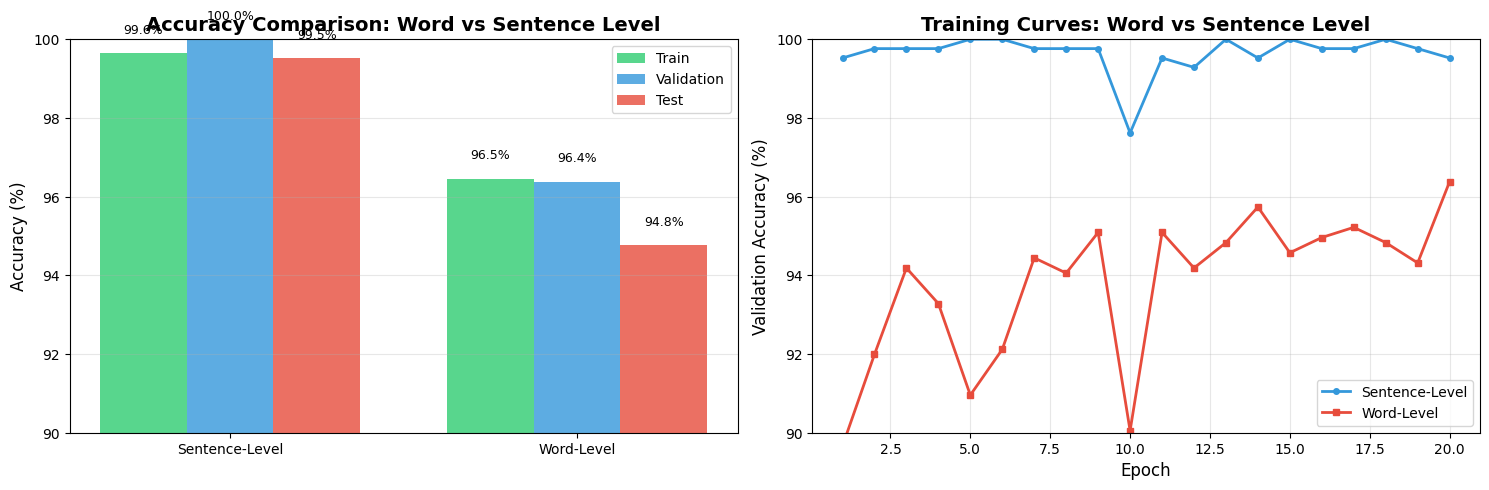

In [27]:
"""
Run Word vs Sentence Level Comparison on Kaggle
Streamlined version optimized for Kaggle GPU environment

Instructions for Kaggle:
1. Upload this script to your Kaggle notebook
2. Enable GPU: Settings → Accelerator → GPU T4 x2
3. Enable Internet: Settings → Internet → On (for downloading HuBERT model)
4. Run: !python run_word_sentence_comparison_kaggle.py
"""

import sys
from pathlib import Path
import json
import pickle
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
import matplotlib.pyplot as plt

# Add paths
sys.path.insert(0, str(Path.cwd()))

# Import project modules
from src.features.hubert_extractor import HuBERTExtractor
from src.models.mlp import MLPClassifier


class SimpleFeatureDataset(Dataset):
    """Simple dataset for pre-extracted features"""
    def __init__(self, features_dict, filepaths, label_encoder=None):
        self.features = []
        self.labels = []
        self.label_encoder = label_encoder if label_encoder else LabelEncoder()
        
        # Convert list format to dict if needed
        if isinstance(features_dict, list):
            temp_dict = {}
            for item in features_dict:
                if isinstance(item, dict) and 'filepath' in item:
                    fp = item['filepath'].replace('\\', '/')
                    
                    # Remove 'data/raw/indian_accents/' prefix for sentence-level
                    # Keep 'word_level/' prefix for word-level
                    if fp.startswith('data/raw/indian_accents/'):
                        fp = fp.replace('data/raw/indian_accents/', '')
                    
                    # Handle different key names for label
                    if 'label' not in item and 'native_language' in item:
                        item['label'] = item['native_language']
                    temp_dict[fp] = item
            features_dict = temp_dict
        
        labels_list = []
        matched = 0
        for fp in filepaths:
            feature_item = None
            
            # Try exact match first
            if fp in features_dict:
                feature_item = features_dict[fp]
            # Try with path normalization
            elif fp.replace('\\', '/') in features_dict:
                normalized = fp.replace('\\', '/')
                feature_item = features_dict[normalized]
            
            if feature_item:
                self.features.append(feature_item['features'])
                # Handle different label key names
                label = feature_item.get('label') or feature_item.get('native_language')
                labels_list.append(label)
                matched += 1
        
        if matched == 0 and len(filepaths) > 0:
            print(f"\n⚠️  WARNING: No paths matched!")
            print(f"  Requested {len(filepaths)} files, matched {matched}")
            if len(filepaths) > 0:
                print(f"  Sample requested path: {filepaths[0]}")
            if features_dict:
                print(f"  Sample feature key: {list(features_dict.keys())[0]}")
        
        if label_encoder is None:
            self.labels = self.label_encoder.fit_transform(labels_list)
        else:
            self.labels = self.label_encoder.transform(labels_list)
    
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, idx):
        return torch.FloatTensor(self.features[idx]), torch.LongTensor([self.labels[idx]])[0]


def create_word_level_dataset_simple():
    """Simplified word-level dataset creation using VAD"""
    import librosa
    import soundfile as sf
    
    print("\n" + "="*80)
    print("STEP 1: Creating Word-Level Dataset")
    print("="*80 + "\n")
    
    # Paths
    metadata_path = Path('data/raw/indian_accents/metadata_with_splits.csv')
    output_dir = Path('data/word_level')
    output_dir.mkdir(parents=True, exist_ok=True)
    
    metadata = pd.read_csv(metadata_path)
    
    # Create output directories
    states = metadata['native_language'].unique()
    for state in states:
        (output_dir / state).mkdir(parents=True, exist_ok=True)
    
    word_level_data = []
    word_count = 0
    
    print(f"Processing {len(metadata)} audio files to extract words...")
    
    for idx, row in tqdm(metadata.iterrows(), total=len(metadata), desc="Extracting words"):
        audio_path = Path('data/raw/indian_accents') / row['filepath']
        
        if not audio_path.exists():
            continue
        
        try:
            # Load audio
            audio, sr = librosa.load(str(audio_path), sr=16000, mono=True)
            
            # Simple energy-based word detection
            frame_length = int(0.025 * sr)  # 25ms
            hop_length = int(0.010 * sr)    # 10ms
            
            energy = librosa.feature.rms(y=audio, frame_length=frame_length, hop_length=hop_length)[0]
            energy_db = librosa.amplitude_to_db(energy, ref=np.max)
            
            # Find speech segments
            is_speech = energy_db > -40  # dB threshold
            
            # Get word boundaries
            word_segments = []
            in_word = False
            word_start = 0
            
            for i, speech in enumerate(is_speech):
                sample_idx = i * hop_length
                
                if speech and not in_word:
                    word_start = sample_idx
                    in_word = True
                elif not speech and in_word:
                    word_end = sample_idx
                    duration = (word_end - word_start) / sr
                    
                    if duration > 0.2:  # At least 200ms
                        word_segments.append((word_start, word_end))
                    
                    in_word = False
            
            if in_word:
                word_segments.append((word_start, len(audio)))
            
            # Limit to 10 words per utterance
            word_segments = word_segments[:10]
            
            # Skip if too few words
            if len(word_segments) < 3:
                continue
            
            # Save word segments
            for word_idx, (start, end) in enumerate(word_segments):
                word_audio = audio[start:end]
                
                if len(word_audio) < sr * 0.2:
                    continue
                
                output_filename = f"{audio_path.stem}_word{word_idx:02d}.wav"
                output_filepath = output_dir / row['native_language'] / output_filename
                
                sf.write(str(output_filepath), word_audio, sr)
                
                word_level_data.append({
                    'filepath': f"word_level/{row['native_language']}/{output_filename}",
                    'native_language': row['native_language'],
                    'split': row['split'],
                    'source_file': row['filepath'],
                    'word_index': word_idx
                })
                
                word_count += 1
        
        except Exception as e:
            print(f"\nError processing {audio_path}: {e}")
            continue
    
    # Save metadata
    word_df = pd.DataFrame(word_level_data)
    word_df.to_csv(output_dir / 'word_level_metadata.csv', index=False)
    
    print(f"\n✓ Word-level dataset created")
    print(f"  Total word segments: {word_count}")
    print(f"  Metadata: {output_dir / 'word_level_metadata.csv'}")
    
    print("\nDistribution by state:")
    print(word_df.groupby('native_language').size())
    
    print("\nDistribution by split:")
    print(word_df.groupby('split').size())
    
    return word_df


def extract_features_for_level(level='sentence', layer=3):
    """Extract HuBERT features for specified level"""
    print(f"\n{'='*80}")
    print(f"STEP 2: Extracting {level.upper()}-Level Features (Layer {layer})")
    print(f"{'='*80}\n")
    
    if level == 'sentence':
        metadata_path = Path('data/raw/indian_accents/metadata_with_splits.csv')
        audio_base = Path('data/raw/indian_accents')
        output_file = Path(f'data/features/indian_accents/hubert_layer{layer}_mean.pkl')
    else:
        metadata_path = Path('data/word_level/word_level_metadata.csv')
        audio_base = Path('data')
        output_file = Path(f'data/features/word_level/hubert_layer{layer}_mean.pkl')
    
    output_file.parent.mkdir(parents=True, exist_ok=True)
    
    # Check if already exists
    if output_file.exists():
        print(f"✓ Features already exist at {output_file}")
        with open(output_file, 'rb') as f:
            features_data = pickle.load(f)
        
        # Check format and report
        num_samples = 0
        if isinstance(features_data, dict):
            num_samples = len(features_data)
            print(f"  Loaded {num_samples} feature samples (dict format)")
        elif isinstance(features_data, list):
            num_samples = len(features_data)
            print(f"  Loaded {num_samples} feature samples (list format)")
        else:
            print(f"  Loaded features (unknown format: {type(features_data)})")
        
        # If empty, delete and re-extract
        if num_samples == 0:
            print(f"  ⚠️  Feature file is empty, re-extracting...")
            output_file.unlink()
        else:
            return output_file
    
    # Load metadata
    metadata = pd.read_csv(metadata_path)
    print(f"Processing {len(metadata)} audio files...")
    
    # Initialize extractor
    extractor = HuBERTExtractor()
    
    features_dict = {}
    errors = 0
    missing_files = 0
    
    for idx, row in tqdm(metadata.iterrows(), total=len(metadata), desc=f"Extracting layer {layer}"):
        # Construct full audio path
        if level == 'sentence':
            audio_path = audio_base / row['filepath']
        else:
            # For word-level, filepath already includes 'word_level/' prefix
            audio_path = Path('data') / row['filepath']
        
        if not audio_path.exists():
            missing_files += 1
            if missing_files <= 3:  # Show first 3 missing files
                print(f"\n  Missing: {audio_path}")
            continue
        
        try:
            # Extract mean pooled features
            result = extractor.extract_from_file(str(audio_path), extract_layer=layer, pooling='mean')
            features = result['embeddings'][f'layer_{layer}']
            
            # Convert to numpy if it's a torch tensor
            if hasattr(features, 'numpy'):
                features = features.numpy()
            
            # Store with normalized path
            norm_path = row['filepath'].replace('\\', '/')
            features_dict[norm_path] = {
                'features': features,
                'label': row['native_language'],
                'split': row['split']
            }
        
        except Exception as e:
            errors += 1
            if errors <= 3:  # Show first 3 errors
                print(f"\n  Error processing {audio_path}: {e}")
            continue
    
    # Save features
    with open(output_file, 'wb') as f:
        pickle.dump(features_dict, f)
    
    print(f"\n✓ Extracted {len(features_dict)} samples")
    if missing_files > 0:
        print(f"  Missing files: {missing_files}")
    if errors > 0:
        print(f"  Errors: {errors}")
    print(f"  Saved to: {output_file}")
    
    return output_file


def train_model(features_path, metadata_path, output_dir, level_name, num_epochs=20):
    """Train MLP classifier on features"""
    print(f"\n{'='*80}")
    print(f"STEP 3: Training on {level_name} Data")
    print(f"{'='*80}\n")
    
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)
    
    # Load features
    with open(features_path, 'rb') as f:
        features_dict = pickle.load(f)
    
    print(f"✓ Loaded {len(features_dict)} feature samples")
    
    # Load metadata and split
    metadata = pd.read_csv(metadata_path)
    
    # FIX PATH FORMAT: Convert Windows backslashes to Linux forward slashes
    if 'filepath' in metadata.columns:
        metadata['filepath'] = metadata['filepath'].str.replace('\\', '/', regex=False)
        print(f"✓ Normalized file paths to Linux format")
    
    train_df = metadata[metadata['split'] == 'train']
    val_df = metadata[metadata['split'] == 'val']
    test_df = metadata[metadata['split'] == 'test']
    
    print(f"✓ Splits - Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
    
    # Convert features_dict from list to dict if needed
    if isinstance(features_dict, list):
        print(f"✓ Converting feature list to dictionary format...")
        # Debug: Check what keys are in the first item
        if len(features_dict) > 0:
            print(f"  Sample item keys: {list(features_dict[0].keys())}")
        
        new_dict = {}
        for item in features_dict:
            if isinstance(item, dict) and 'filepath' in item:
                fp = item['filepath'].replace('\\', '/')
                
                # Remove 'data/raw/indian_accents/' prefix for sentence-level
                # Keep 'word_level/' prefix for word-level
                if fp.startswith('data/raw/indian_accents/'):
                    fp = fp.replace('data/raw/indian_accents/', '')
                
                # Handle different possible key names
                label_key = 'label' if 'label' in item else 'native_language' if 'native_language' in item else None
                
                if label_key:
                    new_dict[fp] = {
                        'features': item['features'],
                        'label': item[label_key],
                        'split': item.get('split', 'train')
                    }
        features_dict = new_dict
        print(f"  Converted {len(features_dict)} feature samples")
    
    # Debug: Check path format matching
    if features_dict:
        sample_feature_path = list(features_dict.keys())[0]
        sample_metadata_path = train_df['filepath'].iloc[0] if len(train_df) > 0 else "N/A"
        print(f"  Sample feature key: {sample_feature_path}")
        print(f"  Sample metadata path: {sample_metadata_path}")
    
    # Create datasets
    train_dataset = SimpleFeatureDataset(features_dict, train_df['filepath'].tolist())
    label_encoder = train_dataset.label_encoder
    val_dataset = SimpleFeatureDataset(features_dict, val_df['filepath'].tolist(), label_encoder=label_encoder)
    test_dataset = SimpleFeatureDataset(features_dict, test_df['filepath'].tolist(), label_encoder=label_encoder)
    
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32)
    test_loader = DataLoader(test_dataset, batch_size=32)
    
    # Model setup
    sample_features, _ = train_dataset[0]
    input_dim = sample_features.shape[0]
    num_classes = len(label_encoder.classes_)
    
    print(f"✓ Dataset created with {len(train_dataset)} samples")
    print(f"  Number of classes: {num_classes}")
    print(f"  Classes: {list(label_encoder.classes_)}")
    print(f"  Feature dimension: {input_dim}")
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"  Using device: {device}")
    
    model = MLPClassifier(input_dim=input_dim, hidden_dims=[256, 128], 
                         num_classes=num_classes, dropout=0.3).to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    
    # Training loop
    history = {'train_acc': [], 'val_acc': []}
    best_val_acc = 0
    best_epoch = 0
    
    print(f"\nTraining for {num_epochs} epochs...\n")
    
    for epoch in range(num_epochs):
        # Train
        model.train()
        train_preds, train_labels = [], []
        
        for features, labels in train_loader:
            features, labels = features.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(features)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_preds.extend(outputs.argmax(dim=1).cpu().numpy())
            train_labels.extend(labels.cpu().numpy())
        
        train_acc = accuracy_score(train_labels, train_preds)
        
        # Validate
        model.eval()
        val_preds, val_labels = [], []
        
        with torch.no_grad():
            for features, labels in val_loader:
                features, labels = features.to(device), labels.to(device)
                outputs = model(features)
                val_preds.extend(outputs.argmax(dim=1).cpu().numpy())
                val_labels.extend(labels.cpu().numpy())
        
        val_acc = accuracy_score(val_labels, val_preds)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        print(f"Epoch {epoch+1:02d}: train_acc={train_acc*100:.2f}% val_acc={val_acc*100:.2f}%")
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch + 1
            torch.save(model.state_dict(), output_path / 'best_model.pt')
    
    # Test
    model.load_state_dict(torch.load(output_path / 'best_model.pt'))
    model.eval()
    test_preds, test_labels = [], []
    
    with torch.no_grad():
        for features, labels in test_loader:
            features, labels = features.to(device), labels.to(device)
            outputs = model(features)
            test_preds.extend(outputs.argmax(dim=1).cpu().numpy())
            test_labels.extend(labels.cpu().numpy())
    
    test_acc = accuracy_score(test_labels, test_preds)
    
    print(f"\n{level_name}: best_val={best_val_acc*100:.2f}% (epoch {best_epoch}) test={test_acc*100:.2f}%")
    
    results = {
        'level': level_name,
        'train_acc': history['train_acc'][-1],
        'val_acc': best_val_acc,
        'test_acc': test_acc,
        'best_epoch': best_epoch,
        'history': history
    }
    
    with open(output_path / 'results.json', 'w') as f:
        json.dump(results, f, indent=2)
    
    return results


def create_comparison_plot(results):
    """Create visualization comparing word vs sentence performance"""
    print(f"\n{'='*80}")
    print("STEP 4: Creating Comparison Plots")
    print(f"{'='*80}\n")
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot 1: Accuracy comparison
    levels = ['Sentence-Level', 'Word-Level']
    train_accs = [results['sentence']['train_acc'] * 100, results['word']['train_acc'] * 100]
    val_accs = [results['sentence']['val_acc'] * 100, results['word']['val_acc'] * 100]
    test_accs = [results['sentence']['test_acc'] * 100, results['word']['test_acc'] * 100]
    
    x = range(len(levels))
    width = 0.25
    
    axes[0].bar([i - width for i in x], train_accs, width, label='Train', alpha=0.8, color='#2ecc71')
    axes[0].bar(x, val_accs, width, label='Validation', alpha=0.8, color='#3498db')
    axes[0].bar([i + width for i in x], test_accs, width, label='Test', alpha=0.8, color='#e74c3c')
    
    axes[0].set_ylabel('Accuracy (%)', fontsize=12)
    axes[0].set_title('Accuracy Comparison: Word vs Sentence Level', fontsize=14, fontweight='bold')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(levels)
    axes[0].legend()
    axes[0].grid(axis='y', alpha=0.3)
    axes[0].set_ylim([90, 100])
    
    # Add value labels on bars
    for i in x:
        axes[0].text(i - width, train_accs[i] + 0.5, f'{train_accs[i]:.1f}%', ha='center', fontsize=9)
        axes[0].text(i, val_accs[i] + 0.5, f'{val_accs[i]:.1f}%', ha='center', fontsize=9)
        axes[0].text(i + width, test_accs[i] + 0.5, f'{test_accs[i]:.1f}%', ha='center', fontsize=9)
    
    # Plot 2: Training curves
    epochs_s = range(1, len(results['sentence']['history']['val_acc']) + 1)
    epochs_w = range(1, len(results['word']['history']['val_acc']) + 1)
    
    axes[1].plot(epochs_s, [acc * 100 for acc in results['sentence']['history']['val_acc']], 
                label='Sentence-Level', marker='o', markersize=4, linewidth=2, color='#3498db')
    axes[1].plot(epochs_w, [acc * 100 for acc in results['word']['history']['val_acc']], 
                label='Word-Level', marker='s', markersize=4, linewidth=2, color='#e74c3c')
    
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Validation Accuracy (%)', fontsize=12)
    axes[1].set_title('Training Curves: Word vs Sentence Level', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    axes[1].set_ylim([90, 100])
    
    plt.tight_layout()
    output_file = 'experiments/word_vs_sentence_comparison.png'
    Path('experiments').mkdir(exist_ok=True)
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"✓ Comparison plot saved to {output_file}")
    
    return output_file


def main():
    """Main execution function"""
    print("\n" + "="*80)
    print("WORD VS SENTENCE LEVEL COMPARISON")
    print("="*80 + "\n")
    
    # Configuration
    LAYER = 3  # Use Layer 3 (best from layer-wise analysis)
    EPOCHS = 20
    
    results = {}
    
    # ========== SENTENCE LEVEL ==========
    # Check if sentence-level results already exist
    sentence_results_path = Path(f'experiments/sentence_level_layer{LAYER}/results.json')
    
    if sentence_results_path.exists():
        print("✓ Loading existing sentence-level results...")
        with open(sentence_results_path, 'r') as f:
            results['sentence'] = json.load(f)
        print(f"  Test Accuracy: {results['sentence']['test_acc']*100:.2f}%")
    else:
        # Extract features for sentence-level
        sentence_features = extract_features_for_level('sentence', layer=LAYER)
        
        # Train on sentence-level
        results['sentence'] = train_model(
            features_path=sentence_features,
            metadata_path='data/raw/indian_accents/metadata_with_splits.csv',
            output_dir=f'experiments/sentence_level_layer{LAYER}',
            level_name='Sentence-Level',
            num_epochs=EPOCHS
        )
    
    # ========== WORD LEVEL ==========
    # Create word-level dataset if needed
    word_metadata_path = Path('data/word_level/word_level_metadata.csv')
    if not word_metadata_path.exists():
        create_word_level_dataset_simple()
    else:
        print("\n✓ Word-level dataset already exists")
        word_df = pd.read_csv(word_metadata_path)
        print(f"  Total word segments: {len(word_df)}")
    
    # Extract features for word-level
    word_features = extract_features_for_level('word', layer=LAYER)
    
    # Train on word-level
    results['word'] = train_model(
        features_path=word_features,
        metadata_path=word_metadata_path,
        output_dir=f'experiments/word_level_layer{LAYER}',
        level_name='Word-Level',
        num_epochs=EPOCHS
    )
    
    # ========== COMPARISON ==========
    # Create comparison plot
    create_comparison_plot(results)
    
    # Save comparison results
    comparison_file = 'experiments/word_sentence_comparison_results.json'
    with open(comparison_file, 'w') as f:
        json.dump(results, f, indent=2)
    
    # Print final summary
    print(f"\n{'='*80}")
    print("FINAL COMPARISON SUMMARY")
    print(f"{'='*80}\n")
    
    print(f"{'Level':<20} {'Train Acc':<12} {'Val Acc':<12} {'Test Acc':<12}")
    print("-" * 56)
    print(f"{'Sentence-Level':<20} {results['sentence']['train_acc']*100:>9.2f}% "
          f"{results['sentence']['val_acc']*100:>10.2f}% {results['sentence']['test_acc']*100:>10.2f}%")
    print(f"{'Word-Level':<20} {results['word']['train_acc']*100:>9.2f}% "
          f"{results['word']['val_acc']*100:>10.2f}% {results['word']['test_acc']*100:>10.2f}%")
    
    print("\n" + "="*80)
    print("ANALYSIS")
    print("="*80)
    
    diff = results['sentence']['test_acc'] - results['word']['test_acc']
    
    if diff > 0.01:
        print(f"✓ Sentence-level performs BETTER by {abs(diff)*100:.2f}%")
        print("  → Longer context provides better accent discrimination")
        print("  → Prosodic and rhythmic patterns are important cues")
        print("  → Sentence-level captures more holistic accent characteristics")
    elif diff < -0.01:
        print(f"✓ Word-level performs BETTER by {abs(diff)*100:.2f}%")
        print("  → Phonetic details at word level are more discriminative")
        print("  → Shorter segments may reduce noise and variability")
        print("  → Word-level features capture fine-grained accent markers")
    else:
        print(f"✓ Both levels perform SIMILARLY (difference: {abs(diff)*100:.2f}%)")
        print("  → Accent information is preserved across granularities")
        print("  → HuBERT captures robust accent features at multiple scales")
    
    print(f"\n✓ Results saved to {comparison_file}")
    print(f"✓ Plot saved to experiments/word_vs_sentence_comparison.png")
    
    print("\n" + "="*80)
    print("WORD VS SENTENCE COMPARISON COMPLETE!")
    print("="*80 + "\n")


if __name__ == '__main__':
    main()


In [2]:
import shutil
from pathlib import Path
import pandas as pd

# Copy from Kaggle input to working directory
source_dir = Path('/kaggle/input/child-audios')  # ← Your uploaded dataset
dest_dir = Path('data/raw/child_audios')
dest_dir.mkdir(parents=True, exist_ok=True)

print("Copying files...")
for file in source_dir.glob('*'):
    shutil.copy(file, dest_dir / file.name)
    print(f"✓ Copied: {file.name}")

# Verify metadata
child_meta = pd.read_csv('data/raw/child_audios/child_metadata.csv')
print(f"\n✓ Loaded {len(child_meta)} child samples")
print(f"\nState distribution:")
print(child_meta['native_language'].value_counts())
print(f"\nFirst few rows:")
print(child_meta.head())

Copying files...
✓ Copied: child_aud2.mp3
✓ Copied: child_aud1.mp3
✓ Copied: child_aud3.mp3
✓ Copied: child_aud4.mp3
✓ Copied: child_aud5.mp3
✓ Copied: child_metadata.csv
✓ Copied: child_aud6.mp3

✓ Loaded 6 child samples

State distribution:
native_language
andhra_pradesh    6
Name: count, dtype: int64

First few rows:
         filename native_language                     filepath age_group
0  child_aud1.mp3  andhra_pradesh  child_audios/child_aud1.mp3     child
1  child_aud2.mp3  andhra_pradesh  child_audios/child_aud2.mp3     child
2  child_aud3.mp3  andhra_pradesh  child_audios/child_aud3.mp3     child
3  child_aud4.mp3  andhra_pradesh  child_audios/child_aud4.mp3     child
4  child_aud5.mp3  andhra_pradesh  child_audios/child_aud5.mp3     child


In [8]:
import os
from pathlib import Path

print("Searching for files in indian-accents dataset...")
print("\n" + "="*60)

# List all files in the indian-accents input
base_path = Path('/kaggle/input/indian-accents')

print(f"Contents of {base_path}:\n")
for item in sorted(base_path.rglob('*')):
    if item.is_file():
        print(f"  {item.relative_to(base_path)}")
    
print("\n" + "="*60)
print("Please share the output so I can fix the paths!")

Searching for files in indian-accents dataset...

Contents of /kaggle/input/indian-accents:

  KAGGLE_README.md
  data/raw/indian_accents/andhra_pradesh/Andhra_speaker (1).wav
  data/raw/indian_accents/andhra_pradesh/Andhra_speaker (10).wav
  data/raw/indian_accents/andhra_pradesh/Andhra_speaker (100).wav
  data/raw/indian_accents/andhra_pradesh/Andhra_speaker (1000).wav
  data/raw/indian_accents/andhra_pradesh/Andhra_speaker (1001).wav
  data/raw/indian_accents/andhra_pradesh/Andhra_speaker (1002).wav
  data/raw/indian_accents/andhra_pradesh/Andhra_speaker (1003).wav
  data/raw/indian_accents/andhra_pradesh/Andhra_speaker (1004).wav
  data/raw/indian_accents/andhra_pradesh/Andhra_speaker (1005).wav
  data/raw/indian_accents/andhra_pradesh/Andhra_speaker (1006).wav
  data/raw/indian_accents/andhra_pradesh/Andhra_speaker (1007).wav
  data/raw/indian_accents/andhra_pradesh/Andhra_speaker (1008).wav
  data/raw/indian_accents/andhra_pradesh/Andhra_speaker (1009).wav
  data/raw/indian_accen

In [9]:
import shutil
from pathlib import Path

print("=" * 70)
print("SETTING UP DATA FOR CROSS-AGE ANALYSIS")
print("=" * 70)

# Create directory structure
Path("data/splits").mkdir(parents=True, exist_ok=True)
Path("data/raw/indian_accents").mkdir(parents=True, exist_ok=True)
Path("data/raw/child_audios").mkdir(parents=True, exist_ok=True)

# Copy split CSVs from indian-accents dataset
print("\n📋 Copying split files...")
for split in ['train.csv', 'val.csv', 'test.csv']:
    src = f'/kaggle/input/indian-accents/data/splits/{split}'
    dst = f'data/splits/{split}'
    shutil.copy(src, dst)
    print(f"  ✅ {split}")

# Copy adult audio files from indian-accents dataset
print("\n🎵 Copying adult audio files...")
src_audio = Path('/kaggle/input/indian-accents/data/raw/indian_accents')
dst_audio = Path('data/raw/indian_accents')

# Copy entire indian_accents directory structure
shutil.copytree(src_audio, dst_audio, dirs_exist_ok=True)
audio_count = len(list(dst_audio.rglob('*.wav')))
print(f"  ✅ Copied {audio_count} adult audio files")

# Copy child audio files from child-audios dataset
print("\n👶 Copying child audio files...")
child_src = Path('/kaggle/input/child-audios')
child_dst = Path('data/raw/child_audios')

for file in child_src.glob('*'):
    shutil.copy(file, child_dst)

child_audio_count = len(list(child_dst.glob('*.mp3')))
print(f"  ✅ Copied {child_audio_count} child audio files")
print(f"  ✅ Copied child_metadata.csv")

# Verify everything is in place
print("\n" + "=" * 70)
print("VERIFICATION")
print("=" * 70)

checks = [
    ("data/splits/train.csv", "Train CSV"),
    ("data/splits/val.csv", "Val CSV"),
    ("data/splits/test.csv", "Test CSV"),
    ("data/raw/indian_accents", "Adult audio directory"),
    ("data/raw/child_audios/child_metadata.csv", "Child metadata"),
]

all_good = True
for path, name in checks:
    if Path(path).exists():
        print(f"  ✅ {name}")
    else:
        print(f"  ❌ {name} - NOT FOUND!")
        all_good = False

print(f"\n{'✅ Setup complete! Ready to run analysis.' if all_good else '❌ Some files missing - check errors above.'}")

SETTING UP DATA FOR CROSS-AGE ANALYSIS

📋 Copying split files...
  ✅ train.csv
  ✅ val.csv
  ✅ test.csv

🎵 Copying adult audio files...
  ✅ Copied 8116 adult audio files

👶 Copying child audio files...
  ✅ Copied 6 child audio files
  ✅ Copied child_metadata.csv

VERIFICATION
  ✅ Train CSV
  ✅ Val CSV
  ✅ Test CSV
  ✅ Adult audio directory
  ✅ Child metadata

✅ Setup complete! Ready to run analysis.


CROSS-AGE GENERALIZATION ANALYSIS: ADULT → CHILD

🔧 Device: cuda

📋 Loading metadata...
  ✅ Adult train: 1958 samples
  ✅ Adult val: 420 samples
  ✅ Adult test: 420 samples
  ✅ Child test: 6 samples

🏷️  Labels: ['andhra_pradesh', 'gujrat', 'jharkhand', 'karnataka', 'kerala', 'tamil']

EXPERIMENT 1: MFCC FEATURES

🎵 Extracting MFCC features...
  → Adult data...


Test: 100%|██████████| 420/420 [00:07<00:00, 54.86it/s]


  → Child data...


Child: 100%|██████████| 6/6 [00:00<00:00, 44.94it/s]


  ✅ Extracted features for 1958 train, 420 val, 419 test, 6 child samples

🤖 Training MFCC model on adult speech...
Epoch 5/20 - Train Acc: 96.32% - Val Acc: 98.33%
Epoch 10/20 - Train Acc: 98.72% - Val Acc: 99.29%
Epoch 15/20 - Train Acc: 99.80% - Val Acc: 99.76%
Epoch 20/20 - Train Acc: 99.44% - Val Acc: 100.00%

📊 Evaluating on adult test set...
  Adult Test Accuracy: 99.28%

👶 Evaluating on child test set...
  Child Test Accuracy: 33.33%
  Generalization Gap: 65.95%

EXPERIMENT 2: HuBERT LAYER 3 FEATURES

🎵 Extracting HuBERT features...


...

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

Test: 100%|██████████| 420/420 [00:12<00:00, 33.33it/s]


  → Child data...


Child: 100%|██████████| 6/6 [00:00<00:00, 33.55it/s]


  ✅ Extracted features for 1958 train, 420 val, 420 test, 6 child samples

🤖 Training HuBERT model on adult speech...
Epoch 5/20 - Train Acc: 99.69% - Val Acc: 99.52%
Epoch 10/20 - Train Acc: 99.95% - Val Acc: 99.52%
Epoch 15/20 - Train Acc: 100.00% - Val Acc: 100.00%
Epoch 20/20 - Train Acc: 100.00% - Val Acc: 99.76%

📊 Evaluating on adult test set...
  Adult Test Accuracy: 99.52%

👶 Evaluating on child test set...
  Child Test Accuracy: 0.00%
  Generalization Gap: 99.52%

CREATING VISUALIZATIONS
  ✅ Saved: experiments/cross_age_comparison.png
  ✅ Saved: experiments/cross_age_results.json

FINAL RESULTS SUMMARY

📊 MFCC:
  Adult Accuracy: 99.28%
  Child Accuracy: 33.33%
  Generalization Gap: 65.95%

📊 HuBERT Layer 3:
  Adult Accuracy: 99.52%
  Child Accuracy: 0.00%
  Generalization Gap: 99.52%

🏆 WINNER: MFCC
  Better age generalization by 33.57%

✅ Analysis complete!
📁 Results saved to experiments/


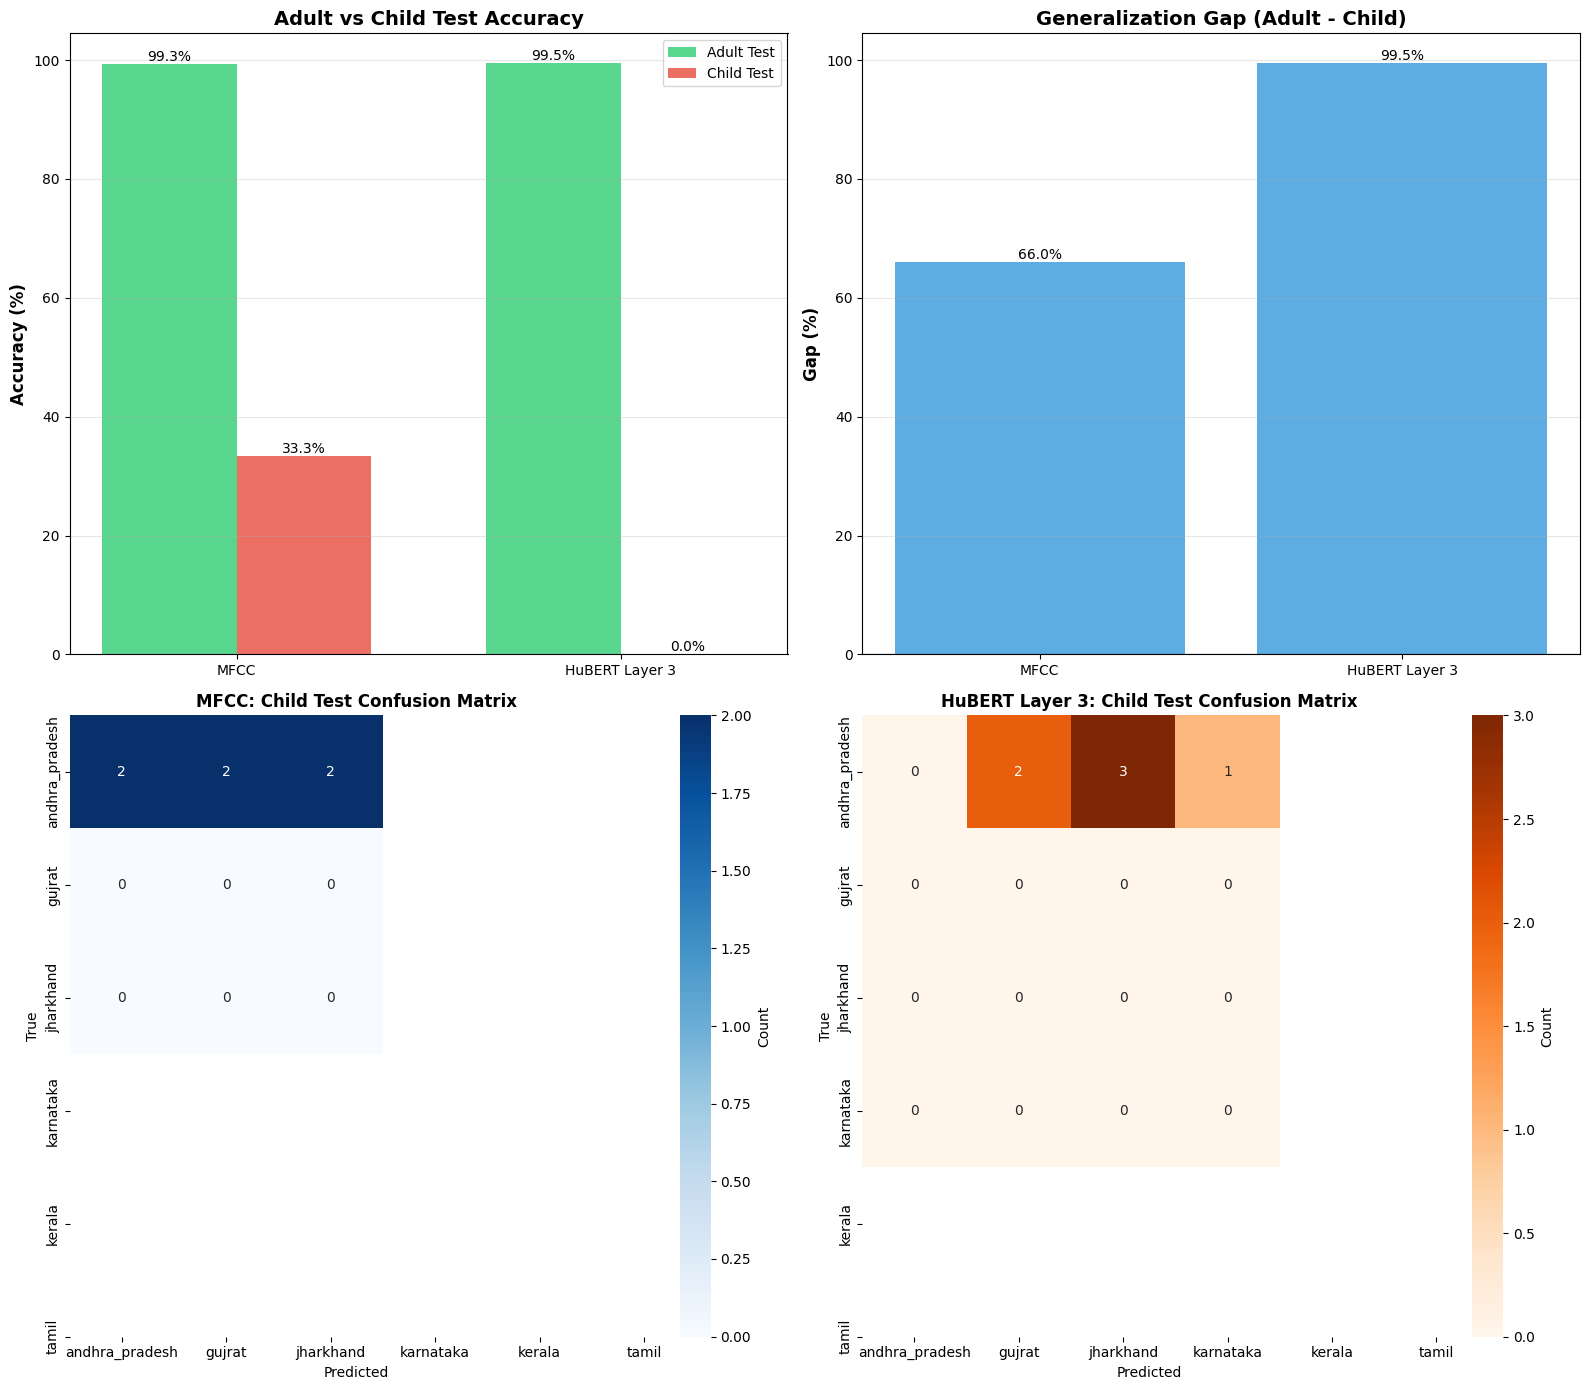

In [14]:
"""
Cross-Age Generalization Analysis - Standalone Version
Train on adult speech, test on children's speech
Compare MFCC vs HuBERT robustness across age groups
"""

import os
import json
import numpy as np
import pandas as pd
import librosa
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import Wav2Vec2FeatureExtractor, HubertModel
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# Feature Extractors
# ============================================================================

class MFCCExtractor:
    """Extract MFCC features from audio"""
    
    def __init__(self, sr=16000, n_mfcc=40):
        self.sr = sr
        self.n_mfcc = n_mfcc
    
    def extract(self, audio_path):
        """Extract MFCC features with delta and delta-delta"""
        audio, _ = librosa.load(audio_path, sr=self.sr)
        
        # MFCC
        mfcc = librosa.feature.mfcc(y=audio, sr=self.sr, n_mfcc=self.n_mfcc)
        mfcc_delta = librosa.feature.delta(mfcc)
        mfcc_delta2 = librosa.feature.delta(mfcc, order=2)
        
        # Concatenate and compute statistics
        features = np.vstack([mfcc, mfcc_delta, mfcc_delta2])
        
        # Mean and std across time
        mean = np.mean(features, axis=1)
        std = np.std(features, axis=1)
        
        return np.concatenate([mean, std])


class HuBERTExtractor:
    """Extract HuBERT features from audio"""
    
    def __init__(self, layer=3, sr=16000):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        # Use Wav2Vec2FeatureExtractor instead of Processor for HuBERT
        self.processor = Wav2Vec2FeatureExtractor.from_pretrained("facebook/hubert-base-ls960")
        self.model = HubertModel.from_pretrained("facebook/hubert-base-ls960").to(self.device)
        self.model.eval()
        self.layer = layer
        self.sr = sr
    
    def extract(self, audio_path):
        """Extract features from specified layer"""
        audio, _ = librosa.load(audio_path, sr=self.sr)
        
        inputs = self.processor(audio, sampling_rate=self.sr, return_tensors="pt", padding=True)
        inputs = {k: v.to(self.device) for k, v in inputs.items()}
        
        with torch.no_grad():
            outputs = self.model(**inputs, output_hidden_states=True)
            hidden_states = outputs.hidden_states[self.layer]
            features = hidden_states.mean(dim=1).squeeze().cpu().numpy()
        
        return features


# ============================================================================
# Dataset
# ============================================================================

class AccentDataset(Dataset):
    """PyTorch dataset for accent classification"""
    
    def __init__(self, features, labels):
        self.features = torch.FloatTensor(features)
        self.labels = torch.LongTensor(labels)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]


# ============================================================================
# Model
# ============================================================================

class MLPClassifier(nn.Module):
    """Multi-layer perceptron for accent classification"""
    
    def __init__(self, input_dim, num_classes, hidden_dims=[256, 128]):
        super().__init__()
        
        layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(0.3)
            ])
            prev_dim = hidden_dim
        
        layers.append(nn.Linear(prev_dim, num_classes))
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)


# ============================================================================
# Training & Evaluation
# ============================================================================

def train_model(model, train_loader, val_loader, num_epochs=20, lr=0.001):
    """Train the model"""
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    best_val_acc = 0
    best_model_state = None
    
    for epoch in range(num_epochs):
        # Training
        model.train()
        train_loss = 0
        train_correct = 0
        train_total = 0
        
        for features, labels in train_loader:
            features, labels = features.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(features)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()
        
        train_acc = 100. * train_correct / train_total
        
        # Validation
        model.eval()
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for features, labels in val_loader:
                features, labels = features.to(device), labels.to(device)
                outputs = model(features)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()
        
        val_acc = 100. * val_correct / val_total
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
        
        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}/{num_epochs} - Train Acc: {train_acc:.2f}% - Val Acc: {val_acc:.2f}%")
    
    # Load best model
    model.load_state_dict(best_model_state)
    return model, best_val_acc


def evaluate_model(model, test_loader, label_names):
    """Evaluate model and return metrics"""
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    model.eval()
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for features, labels in test_loader:
            features = features.to(device)
            outputs = model(features)
            _, predicted = outputs.max(1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    accuracy = accuracy_score(all_labels, all_preds)
    cm = confusion_matrix(all_labels, all_preds)
    
    return accuracy, cm, all_preds, all_labels


def find_audio_file(filepath):
    """Find audio file - CSV paths need 'indian_accents/' prefix"""
    # The CSV has paths like: andhra_pradesh\Andhra_speaker (1002).wav
    # Actual files are at: data/raw/indian_accents/andhra_pradesh/Andhra_speaker (1002).wav
    
    # Convert Windows backslashes to forward slashes
    filepath = filepath.replace('\\', '/')
    
    # Add the indian_accents prefix
    full_path = f"data/raw/indian_accents/{filepath}"
    
    if os.path.exists(full_path):
        return full_path
    
    return None


# ============================================================================
# Main Analysis
# ============================================================================

def main():
    print("=" * 80)
    print("CROSS-AGE GENERALIZATION ANALYSIS: ADULT → CHILD")
    print("=" * 80)
    
    # Set device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"\n🔧 Device: {device}")
    
    # Load metadata
    print("\n📋 Loading metadata...")
    train_df = pd.read_csv('data/splits/train.csv')
    val_df = pd.read_csv('data/splits/val.csv')
    test_df = pd.read_csv('data/splits/test.csv')
    child_df = pd.read_csv('data/raw/child_audios/child_metadata.csv')
    
    print(f"  ✅ Adult train: {len(train_df)} samples")
    print(f"  ✅ Adult val: {len(val_df)} samples")
    print(f"  ✅ Adult test: {len(test_df)} samples")
    print(f"  ✅ Child test: {len(child_df)} samples")
    
    # Get label encoding
    label_names = sorted(train_df['native_language'].unique())
    label_to_idx = {label: idx for idx, label in enumerate(label_names)}
    
    print(f"\n🏷️  Labels: {label_names}")
    
    # Create output directory
    Path('experiments/cross_age_mfcc').mkdir(parents=True, exist_ok=True)
    Path('experiments/cross_age_hubert').mkdir(parents=True, exist_ok=True)
    
    results = {}
    
    # ========================================================================
    # EXPERIMENT 1: MFCC Features
    # ========================================================================
    
    print("\n" + "=" * 80)
    print("EXPERIMENT 1: MFCC FEATURES")
    print("=" * 80)
    
    print("\n🎵 Extracting MFCC features...")
    mfcc_extractor = MFCCExtractor()
    
    # Extract adult features
    print("  → Adult data...")
    train_mfcc = []
    train_labels = []
    missing_count = 0
    for _, row in tqdm(train_df.iterrows(), total=len(train_df), desc="Train"):
        audio_path = find_audio_file(row['filepath'])
        if audio_path:
            try:
                feat = mfcc_extractor.extract(audio_path)
                train_mfcc.append(feat)
                train_labels.append(label_to_idx[row['native_language']])
            except Exception as e:
                missing_count += 1
        else:
            missing_count += 1
    
    if missing_count > 0:
        print(f"  ⚠️  Skipped {missing_count} files")
    
    val_mfcc = []
    val_labels = []
    for _, row in tqdm(val_df.iterrows(), total=len(val_df), desc="Val"):
        audio_path = find_audio_file(row['filepath'])
        if audio_path:
            try:
                feat = mfcc_extractor.extract(audio_path)
                val_mfcc.append(feat)
                val_labels.append(label_to_idx[row['native_language']])
            except:
                pass
    
    test_mfcc = []
    test_labels = []
    for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Test"):
        audio_path = find_audio_file(row['filepath'])
        if audio_path:
            try:
                feat = mfcc_extractor.extract(audio_path)
                test_mfcc.append(feat)
                test_labels.append(label_to_idx[row['native_language']])
            except:
                pass
    
    # Extract child features
    print("  → Child data...")
    child_mfcc = []
    child_labels = []
    for _, row in tqdm(child_df.iterrows(), total=len(child_df), desc="Child"):
        audio_path = f"data/raw/child_audios/{row['filename']}"
        if os.path.exists(audio_path):
            try:
                feat = mfcc_extractor.extract(audio_path)
                child_mfcc.append(feat)
                child_labels.append(label_to_idx[row['native_language']])
            except Exception as e:
                print(f"  ⚠️  Error processing {audio_path}: {e}")
    
    print(f"  ✅ Extracted features for {len(train_mfcc)} train, {len(val_mfcc)} val, {len(test_mfcc)} test, {len(child_mfcc)} child samples")
    
    if len(train_mfcc) == 0:
        print("\n❌ ERROR: No training samples found! Check file paths.")
        return
    
    # Create datasets
    train_dataset = AccentDataset(np.array(train_mfcc), train_labels)
    val_dataset = AccentDataset(np.array(val_mfcc), val_labels)
    test_dataset = AccentDataset(np.array(test_mfcc), test_labels)
    child_dataset = AccentDataset(np.array(child_mfcc), child_labels)
    
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32)
    test_loader = DataLoader(test_dataset, batch_size=32)
    child_loader = DataLoader(child_dataset, batch_size=32)
    
    # Train model
    print("\n🤖 Training MFCC model on adult speech...")
    mfcc_model = MLPClassifier(input_dim=240, num_classes=len(label_names))
    mfcc_model, best_val_acc = train_model(mfcc_model, train_loader, val_loader)
    
    # Save model
    torch.save(mfcc_model.state_dict(), 'experiments/cross_age_mfcc/model.pt')
    
    # Evaluate on adult test set
    print("\n📊 Evaluating on adult test set...")
    adult_acc, adult_cm, _, _ = evaluate_model(mfcc_model, test_loader, label_names)
    print(f"  Adult Test Accuracy: {adult_acc*100:.2f}%")
    
    # Evaluate on child test set
    print("\n👶 Evaluating on child test set...")
    child_acc, child_cm, _, _ = evaluate_model(mfcc_model, child_loader, label_names)
    print(f"  Child Test Accuracy: {child_acc*100:.2f}%")
    
    # Calculate generalization gap
    mfcc_gap = (adult_acc - child_acc) * 100
    print(f"  Generalization Gap: {mfcc_gap:.2f}%")
    
    results['mfcc'] = {
        'adult_accuracy': float(adult_acc),
        'child_accuracy': float(child_acc),
        'generalization_gap': float(mfcc_gap),
        'adult_confusion_matrix': adult_cm.tolist(),
        'child_confusion_matrix': child_cm.tolist()
    }
    
    # ========================================================================
    # EXPERIMENT 2: HuBERT Features
    # ========================================================================
    
    print("\n" + "=" * 80)
    print("EXPERIMENT 2: HuBERT LAYER 3 FEATURES")
    print("=" * 80)
    
    print("\n🎵 Extracting HuBERT features...")
    hubert_extractor = HuBERTExtractor(layer=3)
    
    # Extract adult features
    print("  → Adult data...")
    train_hubert = []
    train_labels = []
    for _, row in tqdm(train_df.iterrows(), total=len(train_df), desc="Train"):
        audio_path = find_audio_file(row['filepath'])
        if audio_path:
            try:
                feat = hubert_extractor.extract(audio_path)
                train_hubert.append(feat)
                train_labels.append(label_to_idx[row['native_language']])
            except:
                pass
    
    val_hubert = []
    val_labels = []
    for _, row in tqdm(val_df.iterrows(), total=len(val_df), desc="Val"):
        audio_path = find_audio_file(row['filepath'])
        if audio_path:
            try:
                feat = hubert_extractor.extract(audio_path)
                val_hubert.append(feat)
                val_labels.append(label_to_idx[row['native_language']])
            except:
                pass
    
    test_hubert = []
    test_labels = []
    for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Test"):
        audio_path = find_audio_file(row['filepath'])
        if audio_path:
            try:
                feat = hubert_extractor.extract(audio_path)
                test_hubert.append(feat)
                test_labels.append(label_to_idx[row['native_language']])
            except:
                pass
    
    # Extract child features
    print("  → Child data...")
    child_hubert = []
    child_labels = []
    for _, row in tqdm(child_df.iterrows(), total=len(child_df), desc="Child"):
        audio_path = f"data/raw/child_audios/{row['filename']}"
        if os.path.exists(audio_path):
            try:
                feat = hubert_extractor.extract(audio_path)
                child_hubert.append(feat)
                child_labels.append(label_to_idx[row['native_language']])
            except Exception as e:
                print(f"  ⚠️  Error processing {audio_path}: {e}")
    
    print(f"  ✅ Extracted features for {len(train_hubert)} train, {len(val_hubert)} val, {len(test_hubert)} test, {len(child_hubert)} child samples")
    
    # Create datasets
    train_dataset = AccentDataset(np.array(train_hubert), train_labels)
    val_dataset = AccentDataset(np.array(val_hubert), val_labels)
    test_dataset = AccentDataset(np.array(test_hubert), test_labels)
    child_dataset = AccentDataset(np.array(child_hubert), child_labels)
    
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32)
    test_loader = DataLoader(test_dataset, batch_size=32)
    child_loader = DataLoader(child_dataset, batch_size=32)
    
    # Train model
    print("\n🤖 Training HuBERT model on adult speech...")
    hubert_model = MLPClassifier(input_dim=768, num_classes=len(label_names))
    hubert_model, best_val_acc = train_model(hubert_model, train_loader, val_loader)
    
    # Save model
    torch.save(hubert_model.state_dict(), 'experiments/cross_age_hubert/model.pt')
    
    # Evaluate on adult test set
    print("\n📊 Evaluating on adult test set...")
    adult_acc, adult_cm, _, _ = evaluate_model(hubert_model, test_loader, label_names)
    print(f"  Adult Test Accuracy: {adult_acc*100:.2f}%")
    
    # Evaluate on child test set
    print("\n👶 Evaluating on child test set...")
    child_acc, child_cm, _, _ = evaluate_model(hubert_model, child_loader, label_names)
    print(f"  Child Test Accuracy: {child_acc*100:.2f}%")
    
    # Calculate generalization gap
    hubert_gap = (adult_acc - child_acc) * 100
    print(f"  Generalization Gap: {hubert_gap:.2f}%")
    
    results['hubert'] = {
        'adult_accuracy': float(adult_acc),
        'child_accuracy': float(child_acc),
        'generalization_gap': float(hubert_gap),
        'adult_confusion_matrix': adult_cm.tolist(),
        'child_confusion_matrix': child_cm.tolist()
    }
    
    # ========================================================================
    # Visualization
    # ========================================================================
    
    print("\n" + "=" * 80)
    print("CREATING VISUALIZATIONS")
    print("=" * 80)
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    
    # Plot 1: Accuracy Comparison
    ax = axes[0, 0]
    x = np.arange(2)
    width = 0.35
    
    adult_accs = [results['mfcc']['adult_accuracy']*100, results['hubert']['adult_accuracy']*100]
    child_accs = [results['mfcc']['child_accuracy']*100, results['hubert']['child_accuracy']*100]
    
    bars1 = ax.bar(x - width/2, adult_accs, width, label='Adult Test', color='#2ecc71', alpha=0.8)
    bars2 = ax.bar(x + width/2, child_accs, width, label='Child Test', color='#e74c3c', alpha=0.8)
    
    ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
    ax.set_title('Adult vs Child Test Accuracy', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(['MFCC', 'HuBERT Layer 3'])
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.1f}%', ha='center', va='bottom', fontsize=10)
    
    # Plot 2: Generalization Gap
    ax = axes[0, 1]
    gaps = [results['mfcc']['generalization_gap'], results['hubert']['generalization_gap']]
    colors = ['#3498db' if gap > 0 else '#e74c3c' for gap in gaps]
    
    bars = ax.bar(['MFCC', 'HuBERT Layer 3'], gaps, color=colors, alpha=0.8)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    ax.set_ylabel('Gap (%)', fontsize=12, fontweight='bold')
    ax.set_title('Generalization Gap (Adult - Child)', fontsize=14, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.1f}%', ha='center', va='bottom' if height > 0 else 'top', fontsize=10)
    
    # Plot 3: MFCC Confusion Matrix (Child)
    ax = axes[1, 0]
    sns.heatmap(results['mfcc']['child_confusion_matrix'], annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names, ax=ax, cbar_kws={'label': 'Count'})
    ax.set_title('MFCC: Child Test Confusion Matrix', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('True', fontsize=10)
    
    # Plot 4: HuBERT Confusion Matrix (Child)
    ax = axes[1, 1]
    sns.heatmap(results['hubert']['child_confusion_matrix'], annot=True, fmt='d', cmap='Oranges',
                xticklabels=label_names, yticklabels=label_names, ax=ax, cbar_kws={'label': 'Count'})
    ax.set_title('HuBERT Layer 3: Child Test Confusion Matrix', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('True', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('experiments/cross_age_comparison.png', dpi=300, bbox_inches='tight')
    print("  ✅ Saved: experiments/cross_age_comparison.png")
    
    # ========================================================================
    # Save Results
    # ========================================================================
    
    # Determine winner
    if abs(results['mfcc']['generalization_gap']) < abs(results['hubert']['generalization_gap']):
        winner = 'MFCC'
        winner_gap = results['mfcc']['generalization_gap']
    else:
        winner = 'HuBERT Layer 3'
        winner_gap = results['hubert']['generalization_gap']
    
    results['summary'] = {
        'winner': winner,
        'winner_gap': float(winner_gap),
        'gap_difference': float(abs(results['mfcc']['generalization_gap'] - results['hubert']['generalization_gap']))
    }
    
    results['label_names'] = label_names
    
    with open('experiments/cross_age_results.json', 'w') as f:
        json.dump(results, f, indent=2)
    print("  ✅ Saved: experiments/cross_age_results.json")
    
    # ========================================================================
    # Summary
    # ========================================================================
    
    print("\n" + "=" * 80)
    print("FINAL RESULTS SUMMARY")
    print("=" * 80)
    
    print("\n📊 MFCC:")
    print(f"  Adult Accuracy: {results['mfcc']['adult_accuracy']*100:.2f}%")
    print(f"  Child Accuracy: {results['mfcc']['child_accuracy']*100:.2f}%")
    print(f"  Generalization Gap: {results['mfcc']['generalization_gap']:.2f}%")
    
    print("\n📊 HuBERT Layer 3:")
    print(f"  Adult Accuracy: {results['hubert']['adult_accuracy']*100:.2f}%")
    print(f"  Child Accuracy: {results['hubert']['child_accuracy']*100:.2f}%")
    print(f"  Generalization Gap: {results['hubert']['generalization_gap']:.2f}%")
    
    print(f"\n🏆 WINNER: {winner}")
    print(f"  Better age generalization by {results['summary']['gap_difference']:.2f}%")
    
    print("\n✅ Analysis complete!")
    print(f"📁 Results saved to experiments/")


if __name__ == "__main__":
    main()